## Q1. Cap Stripping Mechanics

### Data Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from scipy.stats import norm

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('Data')

In [2]:
# Load cap vol time series
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)

# Round maturities to nearest year (BB reports e.g. 0.999 instead of 1.0)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

# Load SOFR swap time series
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100  # percent to decimal

# Load reference rates (SOFR daily)
ref_rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data')
ref_rates['date'] = pd.to_datetime(ref_rates['date'])
ref_rates = ref_rates.set_index('date').sort_index()

sofr_daily = ref_rates['SOFR'].dropna() / 100

# Load validation curves (for 2025-06-30, fully processed)
curves_validation = pd.read_excel(
    DATA_PATH / 'cap_curves_2025-06-30.xlsx',
    sheet_name='rate curves 2025-06-30'
).set_index('tenor')


In [3]:
cap_data.head(5)

maturity,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
date,,,,,,,,,,
2022-03-17,127.3,108.5,109.9,108.5,107.3,104.3,101.0,97.7,95.2,93.2
2022-03-18,96.2,104.9,108.0,108.5,108.0,105.0,101.8,98.3,95.4,93.4
2022-03-21,96.2,105.0,108.1,108.5,107.9,105.0,101.7,98.2,95.4,93.4
2022-03-22,75.1,108.3,115.2,115.3,113.6,109.9,106.3,102.8,99.9,97.5
2022-03-23,94.1,111.0,117.9,117.1,114.6,110.7,107.2,103.5,100.5,98.1


In [4]:
sofr_data.head(5)

maturity,0.25,0.50,0.75,1.00,1.25,1.50,1.75,...,4.50,5.00,6.00,7.00,8.00,9.00,10.00
date,,,,,,,,,,,,,,,
2022-01-03,0.000907,0.002001,0.003068,0.004059,0.004970,0.005920,0.006795,...,0.011550,0.012022,0.012636,0.013149,0.013567,0.013908,0.014237
2022-01-04,0.000908,0.001974,0.002980,0.003949,0.004875,0.005808,0.006670,...,0.011560,0.011996,0.012663,0.013228,0.013667,0.014028,0.014370
2022-01-05,0.000982,0.002180,0.003313,0.004400,0.005390,0.006395,0.007355,...,0.012295,0.012746,0.013410,0.013943,0.014349,0.014678,0.014994
2022-01-06,0.001118,0.002390,0.003569,0.004630,0.005655,0.006670,0.007650,...,0.012745,0.013161,0.013794,0.014285,0.014654,0.014946,0.015240
2022-01-07,0.001143,0.002373,0.003505,0.004584,0.005625,0.006660,0.007665,...,0.013020,0.013440,0.014133,0.014665,0.015058,0.015354,0.015648


In [5]:
ref_rates.head(5)

,DTB3,DFF,SOFR
date,,,
2018-01-01,NaN,1.33,NaN
2018-01-02,1.42,1.42,NaN
2018-01-03,1.39,1.42,NaN
2018-01-04,1.39,1.42,NaN
2018-01-05,1.37,1.42,NaN


In [6]:
curves_validation.head(5)

,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
tenor,,,,,,
0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341


## Question 1: Cap Stripping Mechanics

a). Select a single date from the time series. Using that date’s cap flat vols and SOFR swap curve, build the full processing pipeline:

- Convert Bloomberg normal vols (bp) to Black vols

- Interpolate to a quarterly grid

- Construct discount and forward curves

- Bootstrap forward vols from flat vols

- Validate your pipeline against the processed ```cap_curves_2025-06-30.xlsx``` file.

b) Plot the flat vol and forward vol term structures side by side. The forward vol curve is typically humped: near-term vol reflects current policy uncertainty, while long-term vol reverts to a mean. Describe the shape you observe and explain why it looks that way given where the Fed was in its policy cycle on your chosen date.

c) Repeat Q1b on 3–4 dates spanning the rate cycle (e.g., mid-2022, mid-2023, mid-2024, mid-2025). How does the shape of the forward vol curve change across regimes?



### a)

In [7]:
cap_vols = cap_data.loc['2025-06-30']
SOFR_swaps = sofr_data.loc['2025-06-30']
ref = ref_rates.loc['2025-06-30', 'SOFR']
black_vols = cap_vols / 10000 / SOFR_swaps
black_vols = black_vols.drop(index=0.25)  # Drop 3M vol, which is unreliable and not used in bootstrapping
display(black_vols)
display(SOFR_swaps)
display(ref)

maturity
0.50          NaN
0.75          NaN
1.00     0.181032
1.25          NaN
1.50          NaN
1.75          NaN
2.00     0.261869
2.25          NaN
2.50          NaN
2.75          NaN
3.00     0.285941
3.50          NaN
4.00     0.290875
4.50          NaN
5.00     0.289639
6.00     0.285879
7.00     0.280980
8.00     0.276457
9.00     0.271971
10.00    0.267191
Name: 2025-06-30 00:00:00, dtype: float64

maturity
0.25     0.043019
0.50     0.041467
0.75     0.039991
1.00     0.038667
1.25     0.037205
1.50     0.036121
1.75     0.035409
2.00     0.034903
2.25     0.034435
2.50     0.034177
2.75     0.034045
3.00     0.033993
3.50     0.033879
4.00     0.033967
4.50     0.034055
5.00     0.034284
6.00     0.034770
7.00     0.035305
8.00     0.035846
9.00     0.036364
10.00    0.036865
Name: 2025-06-30 00:00:00, dtype: float64

np.float64(4.45)

#### Quarterly Interpolation

In [8]:
quarterly_vols = pd.Series(index = np.arange(0.5, 10.25, 0.25))
quarterly_vols.loc[black_vols.index] = black_vols.values
quarterly_vols = quarterly_vols.interpolate(method='index') 
quarterly_swaps = pd.Series(index = np.arange(0.25, 10.25, 0.25))
quarterly_swaps.loc[SOFR_swaps.index] = SOFR_swaps.values
quarterly_swaps = quarterly_swaps.interpolate(method='index')
display(quarterly_vols)
display(quarterly_swaps)

0.50          NaN
0.75          NaN
1.00     0.181032
1.25     0.201241
1.50     0.221450
1.75     0.241660
2.00     0.261869
2.25     0.267887
2.50     0.273905
2.75     0.279923
3.00     0.285941
3.25     0.287175
3.50     0.288408
3.75     0.289641
4.00     0.290875
4.25     0.290566
4.50     0.290257
4.75     0.289948
5.00     0.289639
5.25     0.288699
5.50     0.287759
5.75     0.286819
6.00     0.285879
6.25     0.284654
6.50     0.283429
6.75     0.282205
7.00     0.280980
7.25     0.279849
7.50     0.278718
7.75     0.277587
8.00     0.276457
8.25     0.275335
8.50     0.274214
8.75     0.273092
9.00     0.271971
9.25     0.270776
9.50     0.269581
9.75     0.268386
10.00    0.267191
dtype: float64

0.25     0.043019
0.50     0.041467
0.75     0.039991
1.00     0.038667
1.25     0.037205
1.50     0.036121
1.75     0.035409
2.00     0.034903
2.25     0.034435
2.50     0.034177
2.75     0.034045
3.00     0.033993
3.25     0.033936
3.50     0.033879
3.75     0.033923
4.00     0.033967
4.25     0.034011
4.50     0.034055
4.75     0.034170
5.00     0.034284
5.25     0.034405
5.50     0.034527
5.75     0.034648
6.00     0.034770
6.25     0.034904
6.50     0.035037
6.75     0.035171
7.00     0.035305
7.25     0.035440
7.50     0.035576
7.75     0.035711
8.00     0.035846
8.25     0.035976
8.50     0.036105
8.75     0.036235
9.00     0.036364
9.25     0.036489
9.50     0.036615
9.75     0.036740
10.00    0.036865
dtype: float64

#### Discount and Forward Interpolation

In [9]:
discount_factors = {}

for T in sorted(quarterly_swaps.keys()):  # T = 0.25, 0.50, 0.75, 1.00, ...
    R = quarterly_swaps[T]
    known_sum = sum(discount_factors[t] * 0.25 for t in discount_factors)
    discount_factors[T] = (1 - R * known_sum) / (1 + R * 0.25)

forward_rates = {}
tenors = sorted(discount_factors.keys())

for i in range(1, len(tenors)):
    T_prev = tenors[i-1]
    T_curr = tenors[i]
    forward_rates[(T_prev, T_curr)] = (
        np.log(discount_factors[T_prev]) - np.log(discount_factors[T_curr])
    ) / 0.25

discount_factors = pd.Series(discount_factors)
forward_rates = pd.Series(forward_rates)
display(discount_factors)
display(forward_rates)

0.25     0.989360
0.50     0.979589
0.75     0.970611
1.00     0.962282
1.25     0.954827
1.50     0.947586
1.75     0.940296
2.00     0.933008
2.25     0.925935
2.50     0.918639
2.75     0.911199
3.00     0.903655
3.25     0.896213
3.50     0.888859
3.75     0.881242
4.00     0.873670
4.25     0.866141
4.50     0.858657
4.75     0.850913
5.00     0.843186
5.25     0.835444
5.50     0.827719
5.75     0.820009
6.00     0.812317
6.25     0.804574
6.50     0.796846
6.75     0.789132
7.00     0.781433
7.25     0.773739
7.50     0.766061
7.75     0.758400
8.00     0.750757
8.25     0.743173
8.50     0.735609
8.75     0.728066
9.00     0.720544
9.25     0.713077
9.50     0.705633
9.75     0.698214
10.00    0.690818
dtype: float64

0.25  0.50     0.039701
0.50  0.75     0.036827
0.75  1.00     0.034476
1.00  1.25     0.031108
1.25  1.50     0.030449
1.50  1.75     0.030893
1.75  2.00     0.031124
2.00  2.25     0.030439
2.25  2.50     0.031640
2.50  2.75     0.032528
2.75  3.00     0.033254
3.00  3.25     0.033078
3.25  3.50     0.032959
3.50  3.75     0.034425
3.75  4.00     0.034518
4.00  4.25     0.034621
4.25  4.50     0.034715
4.50  4.75     0.036239
4.75  5.00     0.036487
5.00  5.25     0.036896
5.25  5.50     0.037162
5.50  5.75     0.037430
5.75  6.00     0.037700
6.00  6.25     0.038309
6.25  6.50     0.038610
6.50  6.75     0.038912
6.75  7.00     0.039217
7.00  7.25     0.039577
7.25  7.50     0.039889
7.50  7.75     0.040204
7.75  8.00     0.040520
8.00  8.25     0.040613
8.25  8.50     0.040919
8.50  8.75     0.041229
8.75  9.00     0.041540
9.00  9.25     0.041669
9.25  9.50     0.041974
9.50  9.75     0.042282
9.75  10.00    0.042592
dtype: float64

#### Bootstrapping Forward Vol

In [10]:
cap_prices = {}

for maturity in quarterly_vols.index:
    flat_vol = quarterly_vols.loc[maturity]
    caplet_maturities = np.arange(0.5, maturity + 0.25, 0.25)
    caplet_prices = []
    K = quarterly_swaps.loc[maturity]
    for T in caplet_maturities:
        T_expiry = T - 0.25
        forward_rate = forward_rates.get((T - 0.25, T), np.nan)
        discount_rate = discount_factors.get(T, np.nan)

        if np.isnan(forward_rate) or np.isnan(discount_rate):
            break


        d_1 = (np.log(forward_rate / K) + 0.5 * flat_vol**2 * (T_expiry)) / (flat_vol * np.sqrt(T_expiry))
        d_2 = d_1 - flat_vol * np.sqrt(T_expiry)
        if maturity == 2.0:
            print(f"T={T}, T_expiry={T_expiry}, F={forward_rate:.4f}, d1={d_1:.4f}, price={caplet_price:.6f}")

        caplet_price = discount_rate * (forward_rate * norm.cdf(d_1) - K * norm.cdf(d_2)) * 0.25
        caplet_prices.append(caplet_price)

    cap_prices[maturity] = sum(caplet_prices)

cap_prices = pd.Series(cap_prices)
display(cap_prices)

T=0.5, T_expiry=0.25, F=0.0397, d1=1.0492, price=0.000481
T=0.75, T_expiry=0.5, F=0.0368, d1=0.3823, price=0.001277
T=1.0, T_expiry=0.75, F=0.0345, d1=0.0591, price=0.000902
T=1.25, T_expiry=1.0, F=0.0311, d1=-0.3086, price=0.000703
T=1.5, T_expiry=1.25, F=0.0304, d1=-0.3199, price=0.000445
T=1.75, T_expiry=1.5, F=0.0309, d1=-0.2202, price=0.000469
T=2.0, T_expiry=1.75, F=0.0311, d1=-0.1575, price=0.000584


0.50          NaN
0.75          NaN
1.00     0.000951
1.25     0.001718
1.50     0.002646
1.75     0.003746
2.00     0.005055
2.25     0.006240
2.50     0.007555
2.75     0.009006
3.00     0.010595
3.25     0.012085
3.50     0.013628
3.75     0.015294
4.00     0.017020
4.25     0.018703
4.50     0.020424
4.75     0.022256
5.00     0.024129
5.25     0.025994
5.50     0.027889
5.75     0.029812
6.00     0.031762
6.25     0.033724
6.50     0.035707
6.75     0.037709
7.00     0.039728
7.25     0.041781
7.50     0.043849
7.75     0.045933
8.00     0.048030
8.25     0.050127
8.50     0.052235
8.75     0.054352
9.00     0.056477
9.25     0.058583
9.50     0.060693
9.75     0.062807
10.00    0.064924
dtype: float64

In [11]:
for maturity in [2.0]:
    flat_vol = quarterly_vols.loc[maturity]
    K = quarterly_swaps.loc[maturity]
    caplet_maturities = np.arange(0.5, maturity + 0.25, 0.25)
    
    print(f"Cap maturity={maturity}, flat_vol={flat_vol:.4f}, K={K:.4f}")
    total = 0
    for T in caplet_maturities:
        T = round(T, 2)
        T_expiry = round(T - 0.25, 2)
        F = forward_rates.get((T_expiry, T), np.nan)
        D = discount_factors.get(T, np.nan)
        
        d1 = (np.log(F/K) + 0.5 * flat_vol**2 * T_expiry) / (flat_vol * np.sqrt(T_expiry))
        d2 = d1 - flat_vol * np.sqrt(T_expiry)
        cp = D * (F * norm.cdf(d1) - K * norm.cdf(d2)) * 0.25
        total += cp
        print(f"  T={T}, T_expiry={T_expiry}, F={F:.4f}, K={K:.4f}, D={D:.4f}, d1={d1:.4f}, d2={d2:.4f}, cp={cp:.6f}")
    print(f"  Total 2Y cap price: {total:.6f}")

Cap maturity=2.0, flat_vol=0.2619, K=0.0349
  T=0.5, T_expiry=0.25, F=0.0397, K=0.0349, D=0.9796, d1=1.0492, d2=0.9182, cp=0.001277
  T=0.75, T_expiry=0.5, F=0.0368, K=0.0349, D=0.9706, d1=0.3823, d2=0.1972, cp=0.000902
  T=1.0, T_expiry=0.75, F=0.0345, K=0.0349, D=0.9623, d1=0.0591, d2=-0.1677, cp=0.000703
  T=1.25, T_expiry=1.0, F=0.0311, K=0.0349, D=0.9548, d1=-0.3086, d2=-0.5705, cp=0.000445
  T=1.5, T_expiry=1.25, F=0.0304, K=0.0349, D=0.9476, d1=-0.3199, d2=-0.6127, cp=0.000469
  T=1.75, T_expiry=1.5, F=0.0309, K=0.0349, D=0.9403, d1=-0.2202, d2=-0.5409, cp=0.000584
  T=2.0, T_expiry=1.75, F=0.0311, K=0.0349, D=0.9330, d1=-0.1575, d2=-0.5040, cp=0.000675
  Total 2Y cap price: 0.005055


In [12]:
caplet_prices = cap_prices.diff().dropna()
display(caplet_prices)

1.25     0.000767
1.50     0.000928
1.75     0.001101
2.00     0.001309
2.25     0.001185
2.50     0.001315
2.75     0.001451
3.00     0.001589
3.25     0.001489
3.50     0.001543
3.75     0.001666
4.00     0.001725
4.25     0.001684
4.50     0.001720
4.75     0.001832
5.00     0.001873
5.25     0.001865
5.50     0.001895
5.75     0.001923
6.00     0.001950
6.25     0.001962
6.50     0.001983
6.75     0.002002
7.00     0.002019
7.25     0.002052
7.50     0.002069
7.75     0.002084
8.00     0.002097
8.25     0.002097
8.50     0.002108
8.75     0.002117
9.00     0.002125
9.25     0.002106
9.50     0.002110
9.75     0.002114
10.00    0.002116
dtype: float64

In [13]:
from scipy.optimize import brentq

def black_caplet_price(vol, F, K, T_expiry, discount, delta=0.25):
    if T_expiry <= 0 or vol <= 0:
        return 0
    d1 = (np.log(F / K) + 0.5 * vol**2 * T_expiry) / (vol * np.sqrt(T_expiry))
    d2 = d1 - vol * np.sqrt(T_expiry)
    return delta * discount * (F * norm.cdf(d1) - K * norm.cdf(d2))


def bootstrap_forward_vols(cap_prices, forward_rates, discount_factors, swap_rates):
    """
    cap_prices: pd.Series indexed by cap maturity (1.00, 1.25, ..., 10.00)
    """
    forward_vols = {}
    sorted_maturities = sorted(cap_prices.dropna().index)

    for i in range(1, len(sorted_maturities)):
        T_curr = round(sorted_maturities[i], 2)
        T_prev = round(sorted_maturities[i-1], 2)
        T_expiry = T_prev  # option expiry = start of accrual period

        # strip caplet price by differencing adjacent caps
        caplet_price = cap_prices[T_curr] - cap_prices[T_prev]

        F = forward_rates.get((T_expiry, T_curr), np.nan)
        K = swap_rates.get(T_curr, np.nan)  # strike = swap rate at CAP maturity
        discount = discount_factors.get(T_curr, np.nan)

        if any(np.isnan([F, K, discount])) or caplet_price <= 0:
            forward_vols[T_curr] = np.nan
            continue

        try:
            fwd_vol = brentq(
                lambda v: black_caplet_price(v, F, K, T_expiry, discount) - caplet_price,
                1e-6, 5.0,
                xtol=1e-8
            )
        except ValueError:
            raise ValueError(f"Root finding failed for T={T_curr}, F={F:.4f}, K={K:.4f}, caplet_price={caplet_price:.6f}")

        forward_vols[T_curr] = fwd_vol

    return pd.Series(forward_vols)

forward_vols = bootstrap_forward_vols(cap_prices, forward_rates, discount_factors, quarterly_swaps)
display(forward_vols)
display(curves_validation['fwd vols'])

1.25     0.426530
1.50     0.433230
1.75     0.418777
2.00     0.427831
2.25     0.384013
2.50     0.355655
2.75     0.342563
3.00     0.336974
3.25     0.308916
3.50     0.311796
3.75     0.290130
4.00     0.291901
4.25     0.276157
4.50     0.275228
4.75     0.256001
5.00     0.254679
5.25     0.242665
5.50     0.240254
5.75     0.237864
6.00     0.235492
6.25     0.224810
6.50     0.221929
6.75     0.219062
7.00     0.216205
7.25     0.214741
7.50     0.212066
7.75     0.209398
8.00     0.206735
8.25     0.206197
8.50     0.203571
8.75     0.200948
9.00     0.198325
9.25     0.195177
9.50     0.192426
9.75     0.189673
10.00    0.186916
dtype: float64

tenor
0.25          NaN
0.50     0.156842
0.75     0.201708
1.00     0.240464
1.25     0.328341
1.50     0.336521
1.75     0.336809
2.00     0.328654
2.25     0.312413
2.50     0.296022
2.75     0.282155
3.00     0.276057
3.25     0.278780
3.50     0.281472
3.75     0.280533
4.00     0.271292
4.25     0.255268
4.50     0.241018
4.75     0.233740
5.00     0.232622
5.25     0.238613
5.50     0.243270
5.75     0.243416
6.00     0.237775
6.25     0.227010
6.50     0.216967
6.75     0.210060
7.00     0.206982
7.25     0.207593
7.50     0.208720
7.75     0.209430
8.00     0.209561
8.25     0.208884
8.50     0.207743
8.75     0.205962
9.00     0.203424
9.25     0.199919
9.50     0.195520
9.75     0.190017
10.00    0.183291
Name: fwd vols, dtype: float64

#### b)

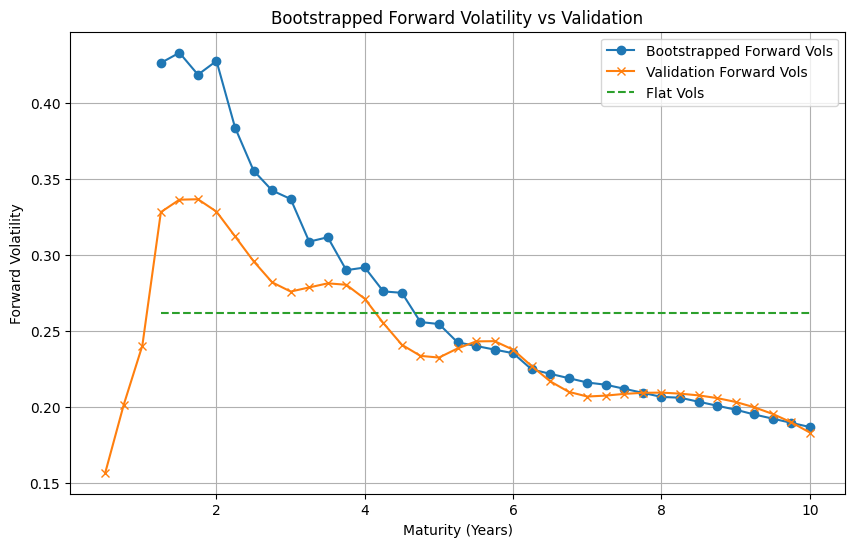

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(forward_vols.index, forward_vols.values, label='Bootstrapped Forward Vols', marker='o')
plt.plot(curves_validation.index, curves_validation['fwd vols'], label='Validation Forward Vols', marker='x')
plt.plot(forward_vols.index, flat_vol * np.ones_like(forward_vols.values), label='Flat Vols', linestyle='--')
plt.xlabel('Maturity (Years)')
plt.ylabel('Forward Volatility')
plt.title('Bootstrapped Forward Volatility vs Validation')
plt.legend()
plt.grid()
plt.show()

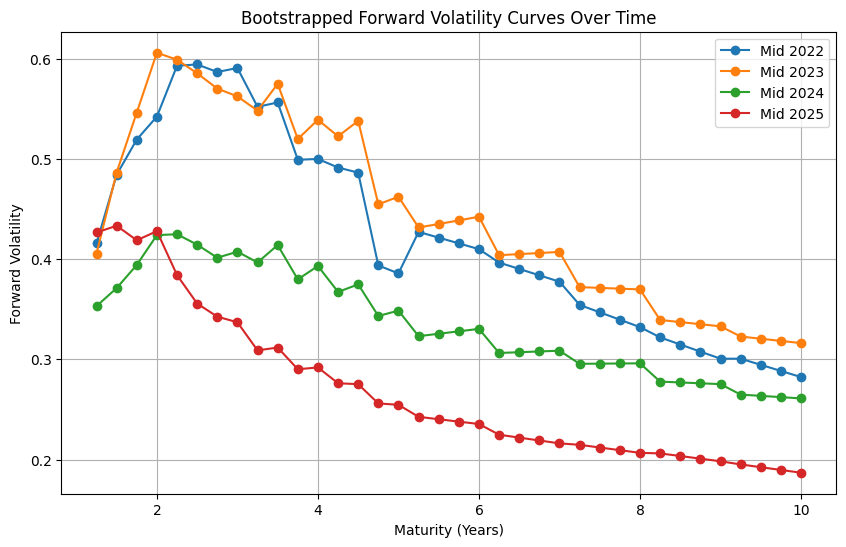

In [17]:
def bootstrapping(cap_vols, SOFR_swaps):
    black_vols = cap_vols / 10000 / SOFR_swaps
    black_vols = black_vols.drop(index=0.25)

    quarterly_vols = pd.Series(index = np.arange(0.5, 10.25, 0.25))
    quarterly_vols.loc[black_vols.index] = black_vols.values
    quarterly_vols = quarterly_vols.interpolate(method='index') 
    quarterly_swaps = pd.Series(index = np.arange(0.25, 10.25, 0.25))
    quarterly_swaps.loc[SOFR_swaps.index] = SOFR_swaps.values
    quarterly_swaps = quarterly_swaps.interpolate(method='index')

    discount_factors = {}

    for T in sorted(quarterly_swaps.keys()):  # T = 0.25, 0.50, 0.75, 1.00, ...
        R = quarterly_swaps[T]
        known_sum = sum(discount_factors[t] * 0.25 for t in discount_factors)
        discount_factors[T] = (1 - R * known_sum) / (1 + R * 0.25)

    forward_rates = {}
    tenors = sorted(discount_factors.keys())

    for i in range(1, len(tenors)):
        T_prev = tenors[i-1]
        T_curr = tenors[i]
        forward_rates[(T_prev, T_curr)] = (
            np.log(discount_factors[T_prev]) - np.log(discount_factors[T_curr])
        ) / 0.25

    discount_factors = pd.Series(discount_factors)
    forward_rates = pd.Series(forward_rates)

    cap_prices = {}

    for maturity in quarterly_vols.index:
        flat_vol = quarterly_vols.loc[maturity]
        caplet_maturities = np.arange(0.5, maturity + 0.25, 0.25)
        caplet_prices = []
        K = quarterly_swaps.loc[maturity]
        for T in caplet_maturities:
            T_expiry = T - 0.25
            forward_rate = forward_rates.get((T - 0.25, T), np.nan)
            discount_rate = discount_factors.get(T, np.nan)

            if np.isnan(forward_rate) or np.isnan(discount_rate):
                break


            d_1 = (np.log(forward_rate / K) + 0.5 * flat_vol**2 * (T_expiry)) / (flat_vol * np.sqrt(T_expiry))
            d_2 = d_1 - flat_vol * np.sqrt(T_expiry)

            caplet_price = discount_rate * (forward_rate * norm.cdf(d_1) - K * norm.cdf(d_2)) * 0.25
            caplet_prices.append(caplet_price)

        cap_prices[maturity] = sum(caplet_prices)

    cap_prices = pd.Series(cap_prices)


    forward_vols = bootstrap_forward_vols(cap_prices, forward_rates, discount_factors, quarterly_swaps)

    return forward_vols


mid_2022 = bootstrapping(cap_vols = cap_data.loc['2022-06-30'], SOFR_swaps = sofr_data.loc['2022-06-30'])
mid_2023 = bootstrapping(cap_vols = cap_data.loc['2023-06-30'], SOFR_swaps = sofr_data.loc['2023-06-30'])
mid_2024 = bootstrapping(cap_vols = cap_data.loc['2024-06-28'], SOFR_swaps = sofr_data.loc['2024-06-28']) 
mid_2025 = bootstrapping(cap_vols = cap_data.loc['2025-06-30'], SOFR_swaps = sofr_data.loc['2025-06-30'])
    
plt.figure(figsize=(10, 6))
plt.plot(mid_2022.index, mid_2022.values, label='Mid 2022', marker='o')
plt.plot(mid_2023.index, mid_2023.values, label='Mid 2023', marker='o')
plt.plot(mid_2024.index, mid_2024.values, label='Mid 2024', marker='o')
plt.plot(mid_2025.index, mid_2025.values, label='Mid 2025', marker='o')
plt.xlabel('Maturity (Years)')
plt.ylabel('Forward Volatility')
plt.title('Bootstrapped Forward Volatility Curves Over Time')
plt.legend()
plt.grid()
plt.show()